In [1]:
# Importing libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ignoring warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset online_retail.xlsx
data = pd.read_excel('online_retail.xlsx')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Dataset exploration
data = data.dropna(subset=["InvoiceDate", "Quantity", "UnitPrice"])
data = data[(data["Quantity"]>0) & (data["UnitPrice"]>0)]

print('Number of rows:', data.shape[0])
print('Number of columns:', data.shape[1])
print('Column names:', data.columns)
print('The starting date of the time serie:', data['InvoiceDate'].min())
print('The end date of the time serie:', data['InvoiceDate'].max())
data.dtypes

Number of rows: 530104
Number of columns: 8
Column names: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
The starting date of the time serie: 2010-12-01 08:26:00
The end date of the time serie: 2011-12-09 12:50:00


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [4]:
# Convert the InvoiceDate to datetime
data['InvoiceDate']= pd.to_datetime(data['InvoiceDate'])
data.dtypes

# remove null values
# data.dropna(inplace = True)
# print('The new number of rows:', len(data))

# create a new column totalsales
data['TotalSales'] = data['Quantity'] * data['UnitPrice']

In [5]:
data.shape

(530104, 9)

In [6]:
# aggregate the total sales by month from the InvoiceDate
sales_time_serie = (
    data.groupby(data['InvoiceDate'].dt.to_period('M'))['TotalSales']
      .sum()
      .reset_index()
)
sales_time_serie["InvoiceDate"] = sales_time_serie["InvoiceDate"].dt.to_timestamp()
sales_time_serie.head()

,InvoiceDate,TotalSales
0,2010-12-01,823746.140
1,2011-01-01,691364.560
2,2011-02-01,523631.890
3,2011-03-01,717639.360
4,2011-04-01,537808.621


In [7]:
# Ensure the result has a proper DateTime index. 
sales_time_serie.set_index('InvoiceDate', inplace=True)

In [8]:
# Verify the cleaned dataset by reviewing summary statistics and sample rows. 
sales_time_serie.describe()

,TotalSales
count,1.300000e+01
mean,8.205142e+05
std,2.725773e+05
min,5.236319e+05
25%,6.913646e+05
50%,7.591384e+05
75%,8.237461e+05
max,1.509496e+06


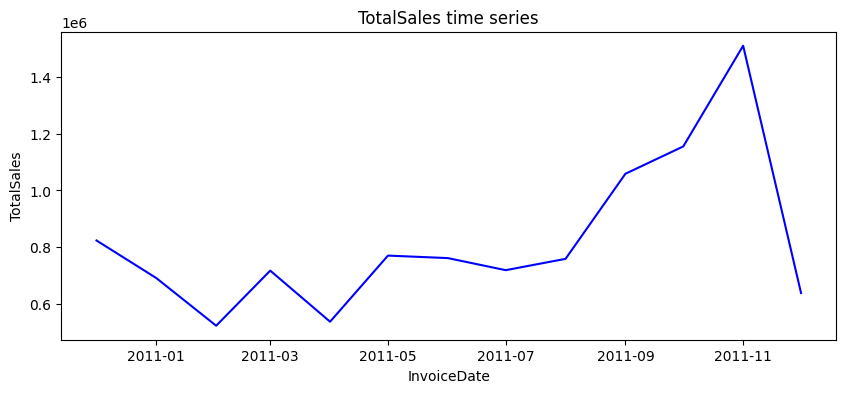

In [9]:
# Plot the monthly sales time series
plt.figure(figsize=(10, 4))
sns.lineplot(x=sales_time_serie.index, y=sales_time_serie['TotalSales'], color='blue')
plt.title('TotalSales time series')
plt.show()

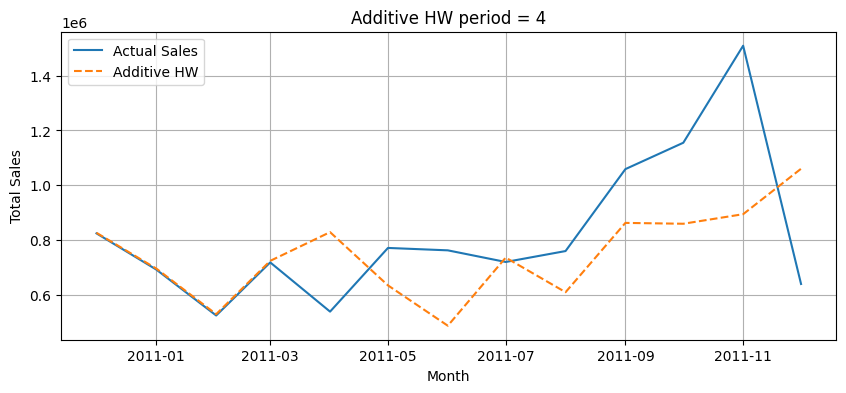

In [10]:
# Apply additive HoltWinters
hw_add_model  = ExponentialSmoothing(sales_time_serie, trend="add", seasonal="add", seasonal_periods=4).fit()

# Generate fitted values
sales_time_serie['HW_Add_Fitted'] = hw_add_model.fittedvalues

# Plot the HW fitted values
plt.figure(figsize=(10, 4))
plt.plot(sales_time_serie['TotalSales'], label="Actual Sales")
plt.plot(sales_time_serie['HW_Add_Fitted'], label="Additive HW", linestyle='dashed')
plt.title("Additive HW period = 4")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()

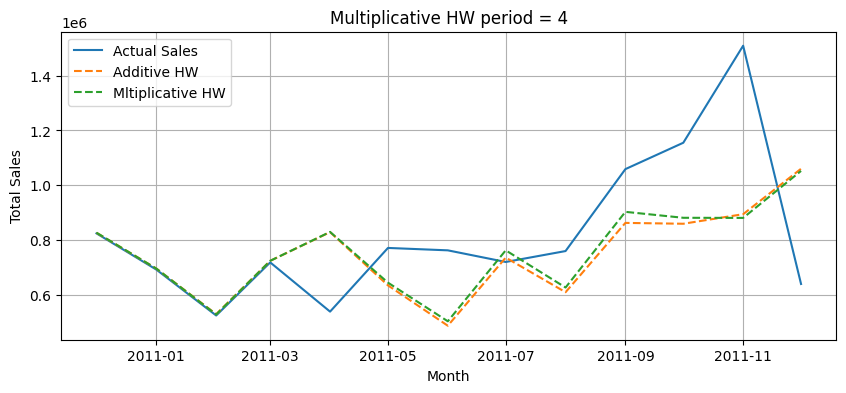

In [11]:
# Apply Multiplicative HoltWinters
hw_mul_model  = ExponentialSmoothing(sales_time_serie['TotalSales'], trend="add", seasonal="mul", seasonal_periods=4).fit()

# Generate fitted values
sales_time_serie['HW_Mul_Fitted'] = hw_mul_model.fittedvalues

# Plot the HW fitted values
plt.figure(figsize=(10,4))
plt.plot(sales_time_serie['TotalSales'], label="Actual Sales")
plt.plot(sales_time_serie['HW_Add_Fitted'], label="Additive HW", linestyle='dashed')
plt.plot(sales_time_serie['HW_Mul_Fitted'], label="Mltiplicative HW", linestyle='--')
plt.title("Multiplicative HW period = 4")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()

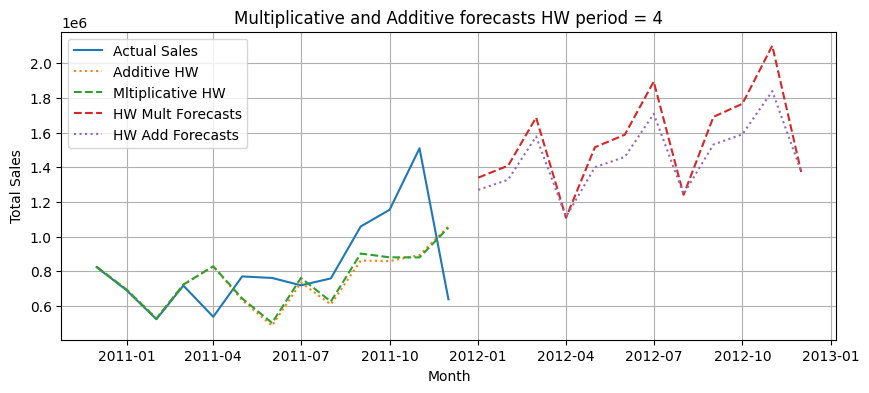

In [12]:
# Generate the 6 months forecast using Hotl Winters
forecast_steps = 12
hw_mul_forecast = hw_mul_model.forecast(forecast_steps)
hw_add_forecast = hw_add_model.forecast(forecast_steps)

# Plot the HW forecasts
plt.figure(figsize=(10,4))
plt.plot(sales_time_serie['TotalSales'], label="Actual Sales")
plt.plot(sales_time_serie['HW_Add_Fitted'], label="Additive HW", linestyle='dotted')
plt.plot(sales_time_serie['HW_Mul_Fitted'], label="Mltiplicative HW", linestyle='--')
plt.plot(hw_mul_forecast, label="HW Mult Forecasts", linestyle='--')
plt.plot(hw_add_forecast, label="HW Add Forecasts", linestyle='dotted')

plt.title("Multiplicative and Additive forecasts HW period = 4")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()

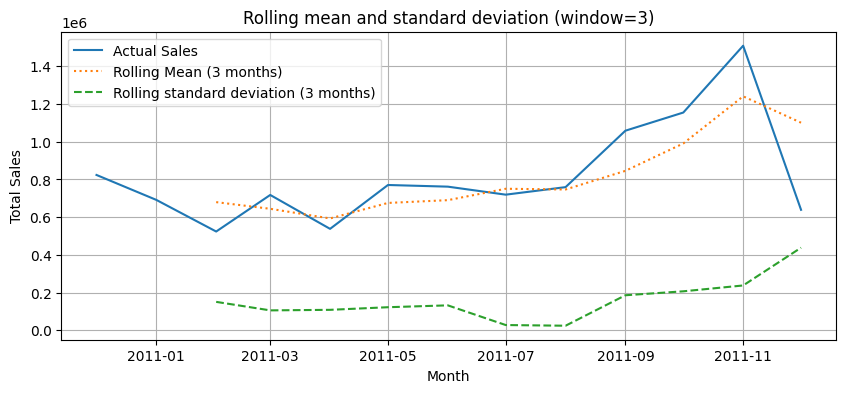

In [13]:
# Check the stationarity of the time series
# calculate the rolling mean and standard deviation to check if they are constant over time
rolling_mean = sales_time_serie['TotalSales'].rolling(window=3).mean()
rolling_std = sales_time_serie['TotalSales'].rolling(window=3).std()

# Plot the rolling mean and stdev
plt.figure(figsize=(10,4))
plt.plot(sales_time_serie['TotalSales'], label="Actual Sales")
plt.plot(rolling_mean, label="Rolling Mean (3 months)", linestyle='dotted')
plt.plot(rolling_std, label="Rolling standard deviation (3 months)", linestyle='--')

plt.title("Rolling mean and standard deviation (window=3)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()

#### 1. Findings: The time series has trending rolling mean and non constant variance. 
#### 2. Conclusion: The time series is not stationary.
#### 3. Apply the differntiation seeking statinarity

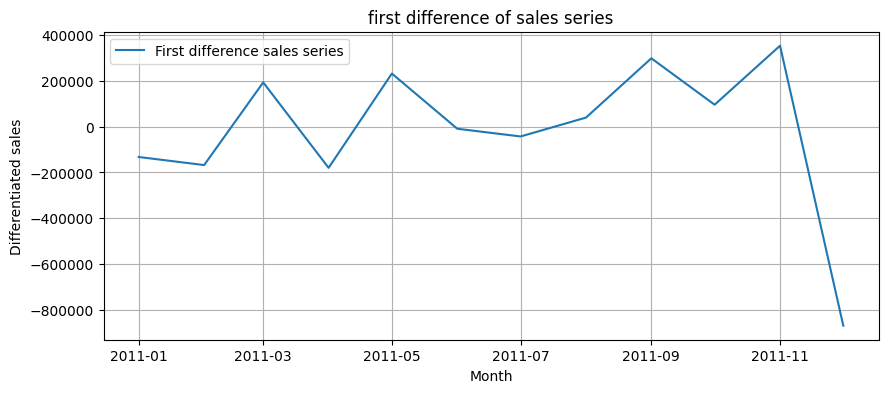

In [14]:
# applying differentiation
sales_diff = sales_time_serie['TotalSales'].diff().dropna()

# Plot the differentiated time series
plt.figure(figsize=(10,4))
plt.plot(sales_diff, label="First difference sales series")

plt.title("first difference of sales series")
plt.xlabel("Month")
plt.ylabel("Differentiated sales")
plt.legend()
plt.grid(True)
plt.show()

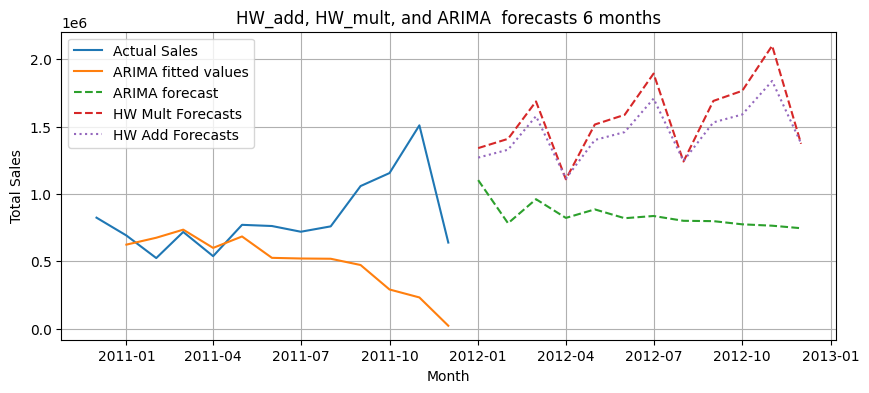

In [15]:
# We implemented the differentiation as ARIMA models require stationary time series
# Fit the ARIMA(p,d,q) model.
# p=1, q=1, d=0 ==> ARIMA(1,0,1)
arima_model = ARIMA(sales_diff, order=(1,0,1))
arima_fit = arima_model.fit()

# Get the ARIMA forecast for the next 6 months
arima_forecast_diff = arima_fit.forecast(steps=forecast_steps)
last_value = sales_time_serie['TotalSales'].iloc[-1]
arima_forecast = last_value + np.cumsum(arima_forecast_diff)

# Obtain the original fitted values by canceling the differentiation
arima_fitted = last_value + np.cumsum(arima_fit.fittedvalues)

# Plot the arima fitted values and forecasts
plt.figure(figsize=(10,4))
plt.plot(sales_time_serie['TotalSales'], label="Actual Sales")
plt.plot(arima_fitted, label="ARIMA fitted values")
plt.plot(arima_forecast, label="ARIMA forecast", linestyle='--')
plt.plot(hw_mul_forecast, label="HW Mult Forecasts", linestyle='--')
plt.plot(hw_add_forecast, label="HW Add Forecasts", linestyle='dotted')

plt.title("HW_add, HW_mult, and ARIMA  forecasts 6 months")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()

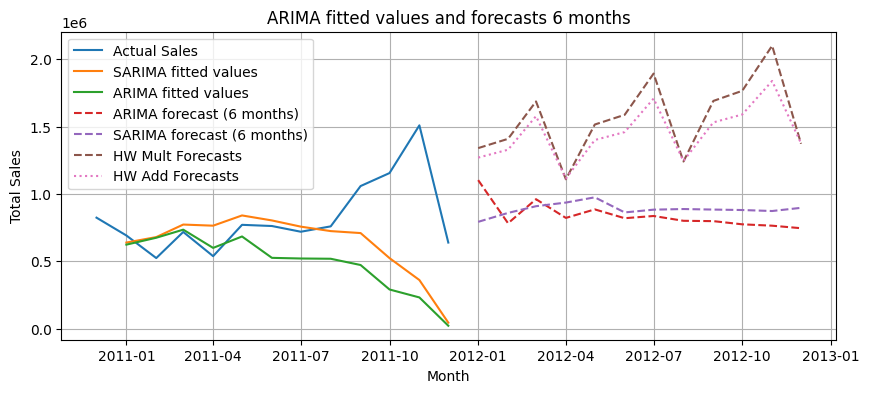

In [16]:
# Define and Fit the SARIMA model (SARIMAX(p,d,q)x(P,D,Q,s))
sarima_model = SARIMAX(sales_diff, order=(1, 0, 1), seasonal_order=(1, 0, 1, 6))
sarima_fit = sarima_model.fit()

# create sarima forecast
sarima_forecast_diff = sarima_fit.forecast(steps=forecast_steps)
last_value = sales_time_serie['TotalSales'].iloc[-1]
sarima_forecast = last_value + np.cumsum(sarima_forecast_diff)

# cancel the differentiation of the sarima fitted values
sarima_fitted = last_value + np.cumsum(sarima_fit.fittedvalues)

# Plot the sarima fitted values and forecasts
plt.figure(figsize=(10,4))
plt.plot(sales_time_serie['TotalSales'], label="Actual Sales")
plt.plot(sarima_fitted, label="SARIMA fitted values")
plt.plot(arima_fitted, label="ARIMA fitted values")
plt.plot(arima_forecast, label="ARIMA forecast (6 months)", linestyle='--')
plt.plot(sarima_forecast, label="SARIMA forecast (6 months)", linestyle='--')
plt.plot(hw_mul_forecast, label="HW Mult Forecasts", linestyle='--')
plt.plot(hw_add_forecast, label="HW Add Forecasts", linestyle='dotted')

plt.title("ARIMA fitted values and forecasts 6 months")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()